1.Install Libraries

In [2]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!wget -q https://downloads.apache.org/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
!tar xf spark-3.5.1-bin-hadoop3.tgz

!pip install pyspark
!pip install pymongo

The system cannot find the path specified.
'wget' is not recognized as an internal or external command,
operable program or batch file.
tar: Error opening archive: Failed to open 'spark-3.5.1-bin-hadoop3.tgz'


DEPRECATION: Python 2.7 reached the end of its life on January 1st, 2020. Please upgrade your Python as Python 2.7 is no longer maintained. pip 21.0 will drop support for Python 2.7 in January 2021. More details about Python 2 support in pip can be found at https://pip.pypa.io/en/latest/development/release-process/#python-2-support pip 21.0 will remove support for this functionality.


DEPRECATION: Python 2.7 reached the end of its life on January 1st, 2020. Please upgrade your Python as Python 2.7 is no longer maintained. pip 21.0 will drop support for Python 2.7 in January 2021. More details about Python 2 support in pip can be found at https://pip.pypa.io/en/latest/development/release-process/#python-2-support pip 21.0 will remove support for this functionality.


In [5]:
import sys
!{sys.executable} -m pip install pyspark pymongo

     ---------------------------------------- 0.0/455.4 MB ? eta -:--:--
     ---------------------------------------- 0.3/455.4 MB ? eta -:--:--
     ---------------------------------------- 1.0/455.4 MB 3.9 MB/s eta 0:01:58
     ---------------------------------------- 1.8/455.4 MB 4.0 MB/s eta 0:01:53
     ---------------------------------------- 2.6/455.4 MB 4.0 MB/s eta 0:01:54
     ---------------------------------------- 3.4/455.4 MB 3.9 MB/s eta 0:01:55
     ---------------------------------------- 4.2/455.4 MB 3.9 MB/s eta 0:01:55
     ---------------------------------------- 5.2/455.4 MB 3.9 MB/s eta 0:01:55
      --------------------------------------- 6.0/455.4 MB 4.0 MB/s eta 0:01:54
      --------------------------------------- 6.8/455.4 MB 4.0 MB/s eta 0:01:54
      --------------------------------------- 7.6/455.4 MB 3.9 MB/s eta 0:01:54
      --------------------------------------- 8.4/455.4 MB 3.9 MB/s eta 0:01:54
      --------------------------------------- 9.2/455.


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2.Create Spark Session

In [6]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MongoTest") \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.3.0") \
    .getOrCreate()

3.Load Dataset

In [7]:
df = spark.read.csv("C:\\Users\\MOHAB\\Downloads\\customers-10000.csv", header=True, inferSchema=True)

# show data
print(df.show(5))

+-----+---------------+----------+---------+--------------------+----------------+--------------------+--------------------+------------------+--------------------+-----------------+--------------------+
|Index|    Customer Id|First Name|Last Name|             Company|            City|             Country|             Phone 1|           Phone 2|               Email|Subscription Date|             Website|
+-----+---------------+----------+---------+--------------------+----------------+--------------------+--------------------+------------------+--------------------+-----------------+--------------------+
|    1|EB54EF1154C3A78|   Heather| Callahan|        Mosley-David|Lake Jeffborough|              Norway|        043-797-5229|      915.112.1727|urangel@espinoza-...|       2020-08-26|http://www.escoba...|
|    2|10dAcafEBbA5FcA|  Kristina|  Ferrell|Horn, Shepard and...|      Aaronville|             Andorra|        932-062-1802|(209)172-7124x3651|xreese@hall-donov...|       2020-04-27|ht

Number of Rows: 10000
Number of Columns: 12


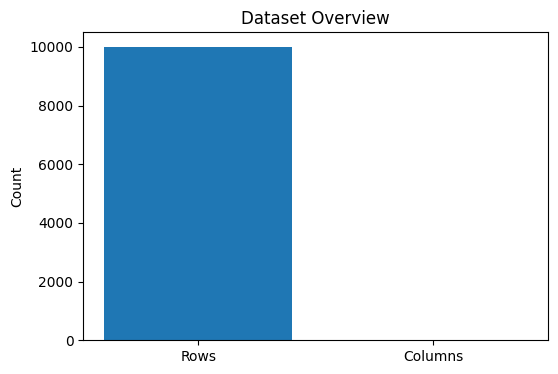

In [8]:
import matplotlib.pyplot as plt

print(f"Number of Rows: {df.count()}")
print(f"Number of Columns: {len(df.columns)}")

plt.figure(figsize=(6, 4))
plt.bar(['Rows', 'Columns'], [df.count(), len(df.columns)])
plt.title('Dataset Overview')
plt.ylabel('Count')
plt.show()

4.Explore Dataset

In [9]:
df.show(5)

+-----+---------------+----------+---------+--------------------+----------------+--------------------+--------------------+------------------+--------------------+-----------------+--------------------+
|Index|    Customer Id|First Name|Last Name|             Company|            City|             Country|             Phone 1|           Phone 2|               Email|Subscription Date|             Website|
+-----+---------------+----------+---------+--------------------+----------------+--------------------+--------------------+------------------+--------------------+-----------------+--------------------+
|    1|EB54EF1154C3A78|   Heather| Callahan|        Mosley-David|Lake Jeffborough|              Norway|        043-797-5229|      915.112.1727|urangel@espinoza-...|       2020-08-26|http://www.escoba...|
|    2|10dAcafEBbA5FcA|  Kristina|  Ferrell|Horn, Shepard and...|      Aaronville|             Andorra|        932-062-1802|(209)172-7124x3651|xreese@hall-donov...|       2020-04-27|ht

In [10]:
df.printSchema()

root
 |-- Index: integer (nullable = true)
 |-- Customer Id: string (nullable = true)
 |-- First Name: string (nullable = true)
 |-- Last Name: string (nullable = true)
 |-- Company: string (nullable = true)
 |-- City: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Phone 1: string (nullable = true)
 |-- Phone 2: string (nullable = true)
 |-- Email: string (nullable = true)
 |-- Subscription Date: date (nullable = true)
 |-- Website: string (nullable = true)



In [11]:
print("Rows:", df.count())

Rows: 10000


5.Data Cleaning

In [12]:
df = df.dropDuplicates()

In [13]:
df = df.na.drop()

In [14]:
original_df = df

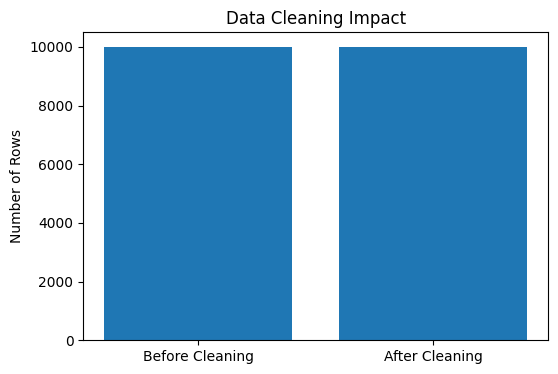

In [15]:
rows_before = original_df.count()
rows_after = df.count()

plt.figure(figsize=(6, 4))
plt.bar(['Before Cleaning', 'After Cleaning'],
        [rows_before, rows_after])
plt.title('Data Cleaning Impact')
plt.ylabel('Number of Rows')
plt.show()

6.Feature Engineering

6.1 Convert Subscription Date

In [16]:
from pyspark.sql.functions import col

df = df.withColumn(
    "Subscription Date",
    col("Subscription Date").cast("date")
)

6.2 Create Tenure

In [17]:
from pyspark.sql.functions import current_date, datediff

df = df.withColumn(
    "tenure_days",
    datediff(current_date(), col("Subscription Date"))
)

In [18]:
import matplotlib.pyplot as plt

def visualize_feature(df, column, title):
    pandas_df = df.select(column).toPandas()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram with fewer bins
    axes[0].hist(pandas_df[column], bins=15, edgecolor='black')
    axes[0].set_title(f'{title} Distribution')
    axes[0].set_xlabel(title)
    axes[0].set_ylabel('Frequency')

    # Boxplot
    axes[1].boxplot(pandas_df[column], vert=True)
    axes[1].set_title(f'{title} Boxplot')
    axes[1].set_ylabel(title)

    plt.tight_layout()
    plt.show()

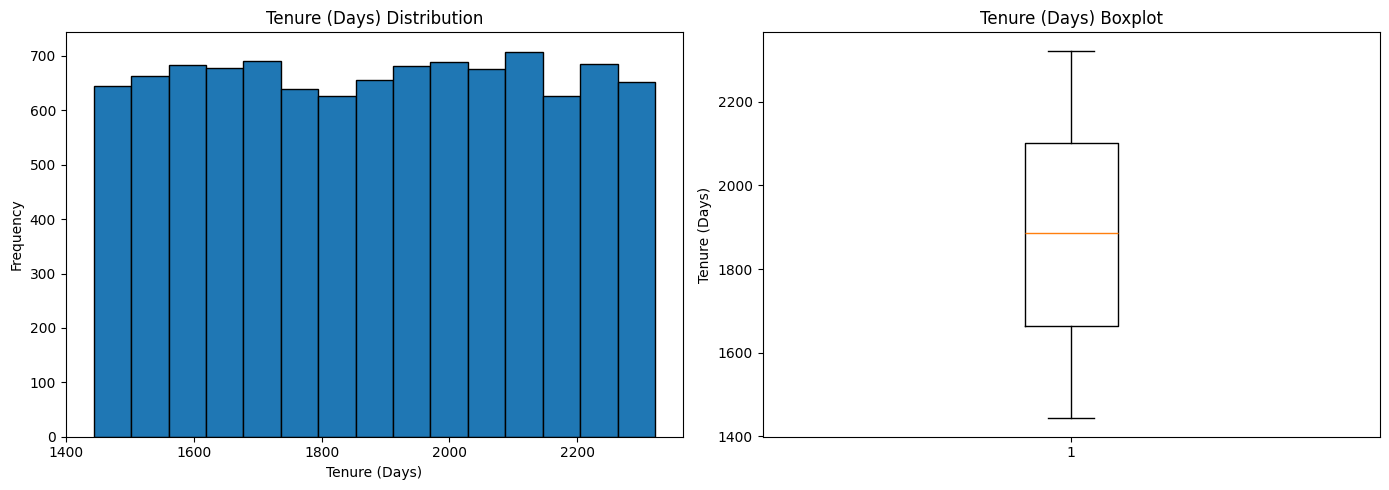

In [19]:
visualize_feature(df, "tenure_days", "Tenure (Days)")

6.3 Create Activity Score



In [20]:
from pyspark.sql.functions import rand

df = df.withColumn(
    "activity_score",
    (rand() * 100).cast("int")
)

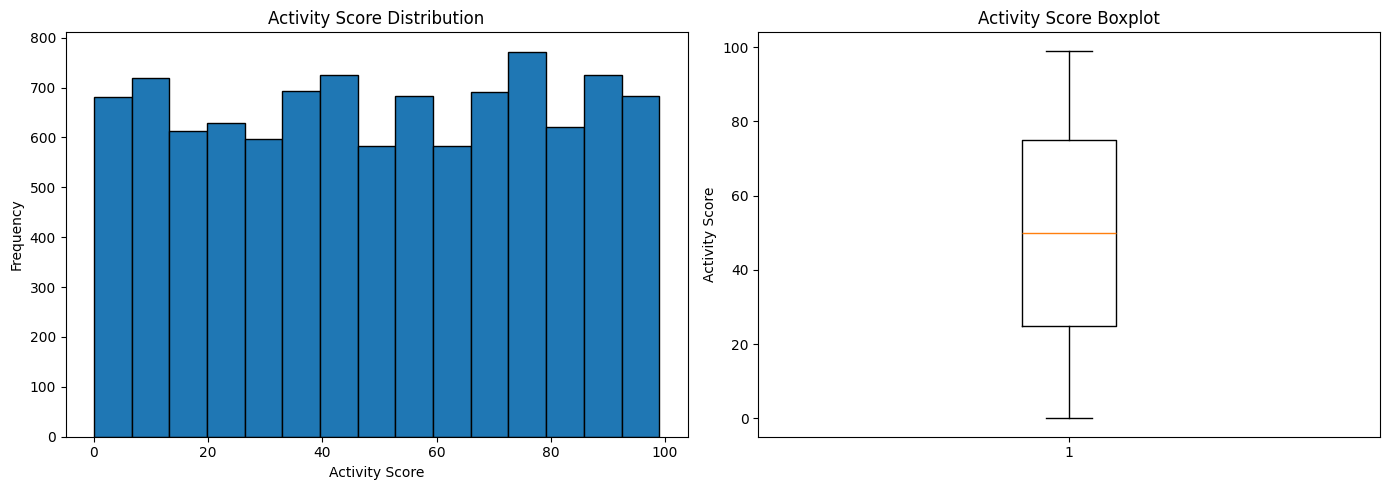

In [21]:
visualize_feature(df, "activity_score", "Activity Score")

6.4 Create Monthly Spending

In [22]:
df = df.withColumn(
    "monthly_spending",
    (rand() * 500).cast("int")
)

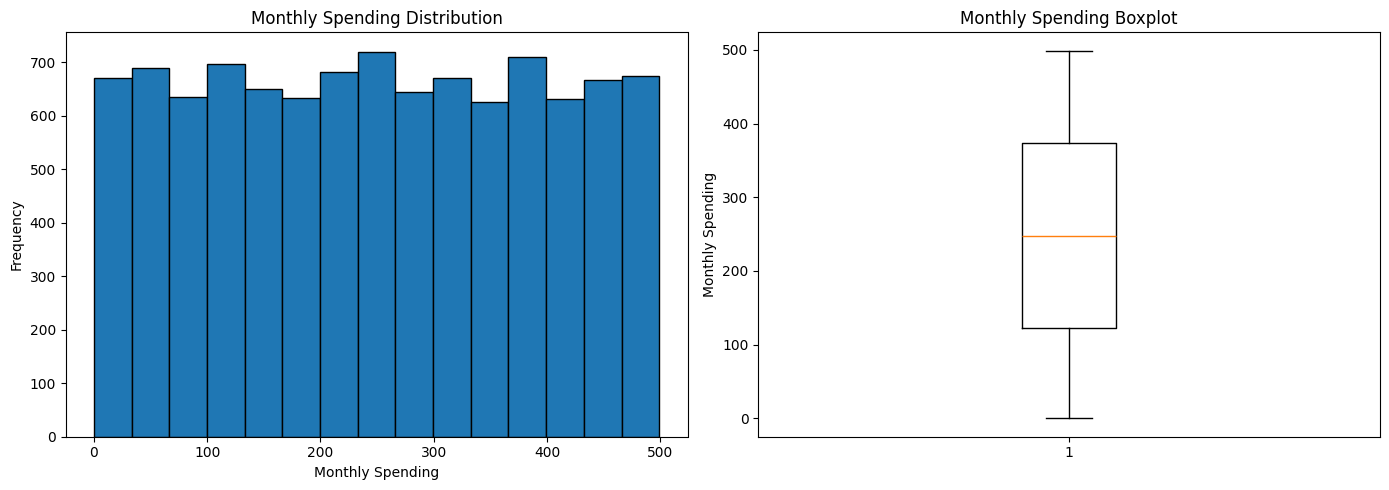

In [23]:
visualize_feature(df, "monthly_spending", "Monthly Spending")

6.5 Create Login Frequency

In [24]:
df = df.withColumn(
    "login_frequency",
    (rand() * 30).cast("int")
)

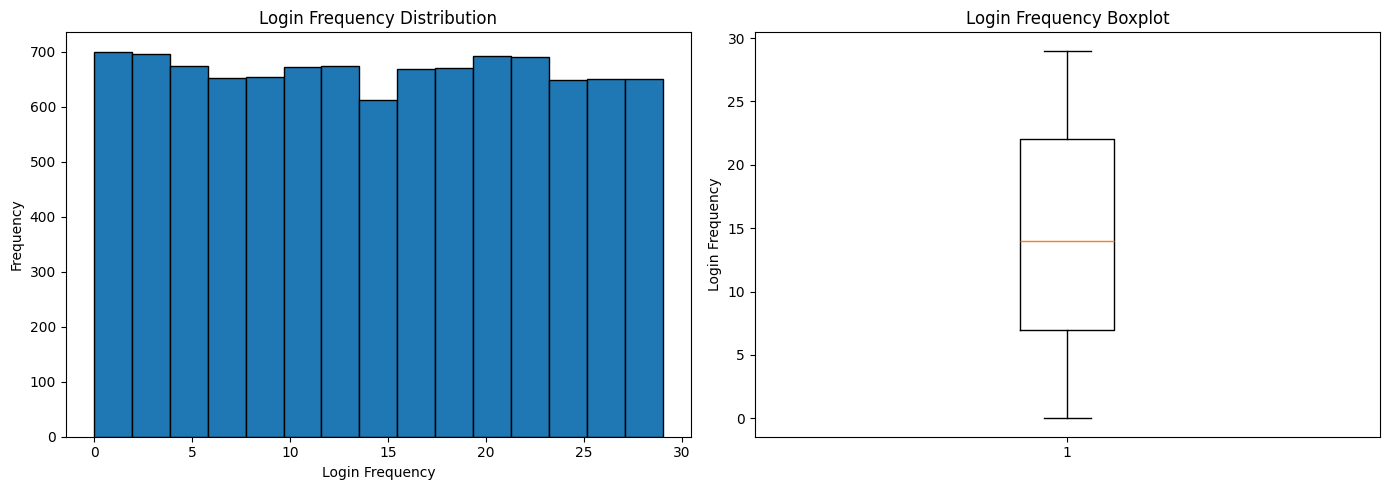

In [25]:
visualize_feature(df, "login_frequency", "Login Frequency")

6.6 Create Support Tickets

In [26]:
df = df.withColumn(
    "support_tickets",
    (rand() * 10).cast("int")
)

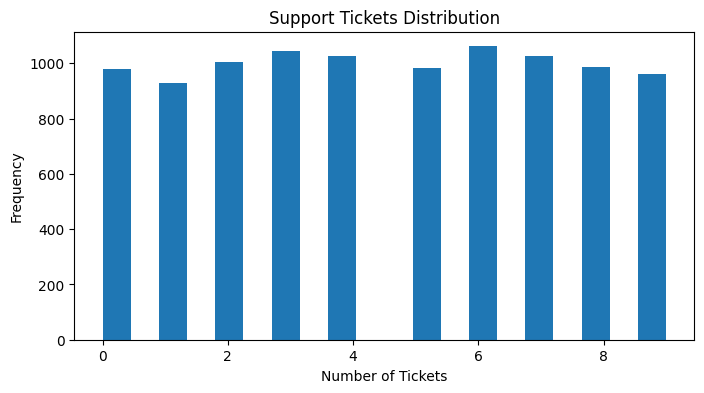

In [27]:
pandas_df = df.select("support_tickets").toPandas()

plt.figure(figsize=(8, 4))
plt.hist(pandas_df["support_tickets"], bins=20)
plt.title('Support Tickets Distribution')
plt.xlabel('Number of Tickets')
plt.ylabel('Frequency')
plt.show()

7. Create Churn Column

7.1 Create Target Column

In [28]:
from pyspark.sql.functions import when

df = df.withColumn(
    "churn",
    when(
        (
            (col("activity_score") < 25) &
            (col("monthly_spending") < 120)
        ) |
        (
            (col("login_frequency") < 5) &
            (col("support_tickets") > 7)
        ),
        1
    ).otherwise(0)
)

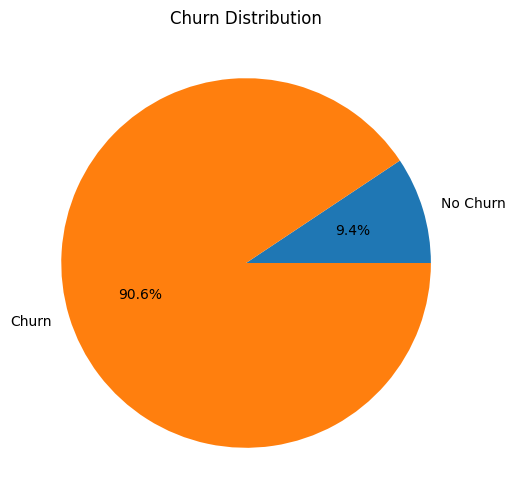

In [29]:
churn_counts = df.groupBy("churn").count().toPandas()

plt.figure(figsize=(6, 6))
plt.pie(
    churn_counts["count"],
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%'
)
plt.title('Churn Distribution')
plt.show()

7.2 Check Class Distribution

In [30]:
df.groupBy("churn").count().show()

+-----+-----+
|churn|count|
+-----+-----+
|    1|  935|
|    0| 9065|
+-----+-----+



8. VectorAssembler

In [31]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "tenure_days",
        "activity_score",
        "monthly_spending",
        "login_frequency"
    ],
    outputCol="features"
)

cluster_data = assembler.transform(df)

9. Apply K-MEANS

In [32]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(
    k=3,
    seed=1
)

kmeans_model = kmeans.fit(cluster_data)

cluster_predictions = kmeans_model.transform(cluster_data)

9.1 Show Clusters

In [33]:
cluster_predictions.select(
    "Customer Id",
    "Country",
    "activity_score",
    "monthly_spending",
    "prediction"
).show()

+---------------+--------------------+--------------+----------------+----------+
|    Customer Id|             Country|activity_score|monthly_spending|prediction|
+---------------+--------------------+--------------+----------------+----------+
|fDbB79FAB142707|          Seychelles|            56|             173|         2|
|Fd126e2a424Bbbc|              Israel|            20|             354|         2|
|80ADdB032adD50C|          Seychelles|            88|             125|         0|
|E460E6eE80f9d46|            Zimbabwe|            23|             170|         1|
|30e4F39fCD9d4bC|               Aruba|            49|              43|         2|
|Dc7EFFe6eEd2C5A|         Timor-Leste|            12|             219|         0|
|bC9488Da1bBDd21|             Bolivia|            70|              72|         2|
|8A9bBbFcEc21842|           Sri Lanka|            43|               2|         1|
|C5B71ffCd6feA2E|            Anguilla|            12|             308|         0|
|B8EF5fa82Cf2eE5

10. Split Data

In [34]:
train_data, test_data = cluster_data.randomSplit(
    [0.8, 0.2],
    seed=42
)

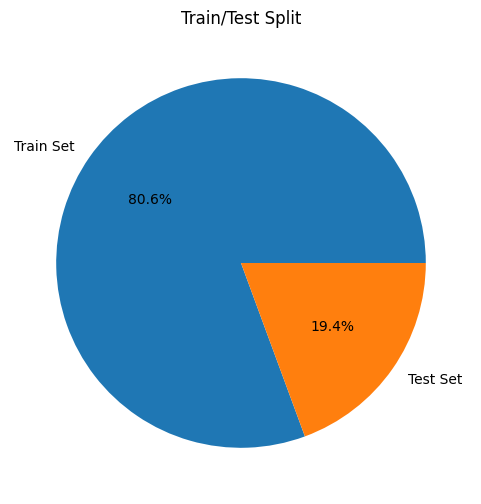

In [35]:
train_count = train_data.count()
test_count = test_data.count()

plt.figure(figsize=(6, 6))
plt.pie(
    [train_count, test_count],
    labels=['Train Set', 'Test Set'],
    autopct='%1.1f%%'
)
plt.title('Train/Test Split')
plt.show()

11. Logistic Regression

In [36]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="churn"
)

lr_model = lr.fit(train_data)

12.Make Predictions

In [37]:
predictions = lr_model.transform(test_data)

13.Show Results

In [38]:
predictions.select(
    "Customer Id",
    "churn",
    "prediction",
    "probability"
).show()

+---------------+-----+----------+--------------------+
|    Customer Id|churn|prediction|         probability|
+---------------+-----+----------+--------------------+
|6d350C5E5eDB4EE|    0|       0.0|[0.97890775296526...|
|e586A2D67bcdB48|    0|       0.0|[0.99917125527685...|
|48b3ACBfD6A5cdC|    0|       0.0|[0.85227070362588...|
|84d3FaE8D176217|    0|       0.0|[0.96971620917136...|
|53D27CbE3b3CAf7|    1|       0.0|[0.88307032366541...|
|E95Ce6e2d241660|    0|       0.0|[0.93113382255002...|
|30Cb5c2C58061ef|    0|       0.0|[0.84123079452781...|
|21C1a2E1e9Cf6cC|    0|       0.0|[0.90129524372897...|
|5EDb197afE9965F|    1|       0.0|[0.64009062665478...|
|0eFf84b706a8DdB|    1|       0.0|[0.68948544327062...|
|29A8E562DC75ede|    0|       0.0|[0.62274598650984...|
|b7CC9cA6676F4Ac|    0|       0.0|[0.99768185960031...|
|6AFE9e8b5dCEbA0|    1|       1.0|[0.33092226075421...|
|1ECAA049CCaAA7B|    0|       0.0|[0.99882550302912...|
|B7C08CBAe87F63b|    1|       1.0|[0.39087845220

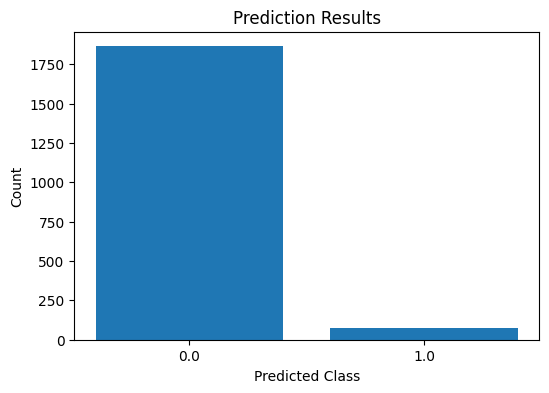

In [39]:
pred_counts = predictions.groupBy("prediction").count().toPandas()

plt.figure(figsize=(6, 4))
plt.bar(
    pred_counts["prediction"].astype(str),
    pred_counts["count"]
)
plt.title('Prediction Results')
plt.xlabel('Predicted Class')
plt.ylabel('Count')
plt.show()

14. Evaluate Model

In [40]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="churn",
    predictionCol="prediction",
    metricName="f1"
)

f1 = evaluator.evaluate(predictions)

print("F1 Score:", f1)

F1 Score: 0.9171510591503194


15. Accuracy

In [41]:
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="churn",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = accuracy_evaluator.evaluate(predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9303405572755418


16.connection to mongo

16.1 Install / Import Libraries

In [43]:
from pymongo import MongoClient
import pandas as pd

16.2 Create MongoDB Connection

In [44]:
client = MongoClient("mongodb://localhost:27017/")

16.3 Create Database

In [45]:
db = client["myProjectDB"]

16.4 Create Collection

In [46]:
collection = db["customers"]

16.5 Convert Spark DataFrame → Pandas

In [47]:
pandas_df = df.toPandas()

16.6 Convert Data to Dictionary Format

In [54]:
data = pandas_df.to_dict("records")


16.7 Insert Data into MongoDB

In [57]:
print(pandas_df.head())

   Index      Customer Id First Name   Last Name                      Company  \
0     36  fDbB79FAB142707    Francis     Hubbard                 Barron Group   
1    349  Fd126e2a424Bbbc     Briana     Barnett  Morgan, Horton and Martinez   
2    777  80ADdB032adD50C  Gabriella  Hutchinson              Trevino-Hawkins   
3   1087  E460E6eE80f9d46     Samuel       Riggs              Alexander Group   
4   1133  30e4F39fCD9d4bC      Amber       Haney              Robertson-Hines   

                 City     Country               Phone 1             Phone 2  \
0     West Makaylaton  Seychelles  +1-895-654-6918x3859  (182)766-9394x4641   
1   Lake Dianachester      Israel      001-762-714-6896        463-501-5962   
2       Chambersshire  Seychelles            7219771564        679.517.4215   
3  Christensenborough    Zimbabwe      200-285-5550x599        704.712.0151   
4     West Graceburgh       Aruba         (731)321-8580    249-558-3443x362   

                             Email Sub

In [58]:
data = pandas_df.to_dict("records")

In [59]:
print(type(data))
print(type(data[0]))
print(data[0])

<class 'list'>
<class 'dict'>
{'Index': 36, 'Customer Id': 'fDbB79FAB142707', 'First Name': 'Francis', 'Last Name': 'Hubbard', 'Company': 'Barron Group', 'City': 'West Makaylaton', 'Country': 'Seychelles', 'Phone 1': '+1-895-654-6918x3859', 'Phone 2': '(182)766-9394x4641', 'Email': 'savannah10@simpson.com', 'Subscription Date': '2021-03-17', 'Website': 'https://www.velazquez-wright.com/', 'tenure_days': 1881, 'activity_score': 56, 'monthly_spending': 173, 'login_frequency': 19, 'support_tickets': 0, 'churn': 0}


In [60]:
collection.insert_many(data)

print("Done inserted successfully")

Done inserted successfully


16.8 Verify Data (Test Step)

In [61]:
for doc in collection.find().limit(5):
    print(doc)

{'_id': ObjectId('69e9042b09d68acf84f30a4b'), 'Index': 1, 'Customer Id': 'EB54EF1154C3A78', 'First Name': 'Heather', 'Last Name': 'Callahan', 'Company': 'Mosley-David', 'City': 'Lake Jeffborough', 'Country': 'Norway', 'Phone 1': '043-797-5229', 'Phone 2': '915.112.1727', 'Email': 'urangel@espinoza-francis.net', 'Subscription Date': '2020-08-26', 'Website': 'http://www.escobar.org/'}
{'_id': ObjectId('69e9042b09d68acf84f30a4c'), 'Index': 3, 'Customer Id': '67DAB15Ebe4BE4a', 'First Name': 'Briana', 'Last Name': 'Andersen', 'Company': 'Irwin-Oneal', 'City': 'East Jordan', 'Country': 'Nepal', 'Phone 1': '8352752061', 'Phone 2': '(567)135-1918', 'Email': 'haleybraun@blevins-sexton.com', 'Subscription Date': '2022-03-22', 'Website': 'https://www.mack-bell.net/'}
{'_id': ObjectId('69e9042b09d68acf84f30a4d'), 'Index': 2, 'Customer Id': '10dAcafEBbA5FcA', 'First Name': 'Kristina', 'Last Name': 'Ferrell', 'Company': 'Horn, Shepard and Watson', 'City': 'Aaronville', 'Country': 'Andorra', 'Phone 1

16.9 Check in MongoDB Compass

In [64]:
print(client.list_database_names())

['admin', 'amitdb', 'config', 'local', 'myProjectDB']


17. test

In [65]:
collection.insert_one({
    "test": "hello from pc",
    "status": "working",
    "value": 123
})
print("Inserted")

Inserted


In [67]:
for doc in collection.find({"Country": "Norway"}).limit(5):
    print(doc)

{'_id': ObjectId('69e9042b09d68acf84f30a4b'), 'Index': 1, 'Customer Id': 'EB54EF1154C3A78', 'First Name': 'Heather', 'Last Name': 'Callahan', 'Company': 'Mosley-David', 'City': 'Lake Jeffborough', 'Country': 'Norway', 'Phone 1': '043-797-5229', 'Phone 2': '915.112.1727', 'Email': 'urangel@espinoza-francis.net', 'Subscription Date': '2020-08-26', 'Website': 'http://www.escobar.org/'}
{'_id': ObjectId('69e9042b09d68acf84f30b27'), 'Index': 234, 'Customer Id': 'bA3c7355abEB0Aa', 'First Name': 'Danielle', 'Last Name': 'Huang', 'Company': 'Bailey, Dorsey and Tanner', 'City': 'Port Robert', 'Country': 'Norway', 'Phone 1': '4899460466', 'Phone 2': '(309)944-0313', 'Email': 'ericksoncheyenne@taylor.com', 'Subscription Date': '2020-10-09', 'Website': 'https://harris-houston.biz/'}
{'_id': ObjectId('69e9042b09d68acf84f30b63'), 'Index': 294, 'Customer Id': '78ac17Cc0E0b444', 'First Name': 'Danny', 'Last Name': 'Hall', 'Company': 'Coleman, Berg and Larsen', 'City': 'Harrellland', 'Country': 'Norway